In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
curr_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/custChurn_v1.csv")
curr_df

,total_orders,total_spent,average_order_value,total_returns,return_rate,loyalty_points,last_purchase_days,purchase_frequency,lifetime_value,customer_segment,...,return_reason,seller_rating,customer_rating,payment_method_y,payment_status,payment_failures,refund_amount,subscription_active,subscription_fee,average_monthly_spend
0,82,145985.42,1780.31,4,0.049,1459,125,5.79,311103.65,Loyal,...,Changed Mind,3.4,3,Credit Card,Refunded,0,0.0,Yes,199,14960.23
1,87,784538.16,9017.68,8,0.092,7845,44,2.43,897900.59,High Value,...,Changed Mind,3.8,3,Credit Card,Failed,4,0.0,Yes,999,1119.76
2,12,36172.08,3014.34,8,0.667,361,308,4.68,49858.61,At Risk,...,Not applicable,4.3,4,UPI,Success,5,0.0,Yes,999,4798.59
3,84,719480.16,8565.24,6,0.071,7194,112,3.05,1071641.95,High Value,...,Changed Mind,4.5,1,Debit Card,Success,0,0.0,No,0,3531.85
4,84,719480.16,8565.24,6,0.071,7194,112,3.05,1071641.95,High Value,...,Not mentioned,3.1,4,Debit Card,Success,0,0.0,No,0,3531.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,57,44145.36,774.48,1,0.018,441,347,0.99,74282.84,At Risk,...,Not applicable,4.3,1,COD,Refunded,2,0.0,No,0,18464.58
999996,57,44145.36,774.48,1,0.018,441,347,0.99,74282.84,At Risk,...,Not applicable,3.5,1,COD,Refunded,2,0.0,No,0,18464.58
999997,57,44145.36,774.48,1,0.018,441,347,0.99,74282.84,At Risk,...,Wrong Item,4.4,1,COD,Refunded,2,0.0,No,0,18464.58
999998,76,94524.24,1243.74,8,0.105,945,259,2.85,143464.49,At Risk,...,Not applicable,4.8,4,Wallet,Success,1,0.0,No,0,19173.44


In [4]:
X = curr_df.drop(columns=["churn"])
y = curr_df["churn"].map({"No": 0, "Yes": 1})

In [5]:
y.value_counts()

,count
churn,
0,792787
1,207213


In [6]:
curr_df.duplicated().sum()

np.int64(0)

In [7]:
numeric_cols = curr_df.select_dtypes(include=["int64", "float64"]).columns

(curr_df[numeric_cols] < 0).sum().sort_values(ascending=False)

,0
total_orders,0
total_spent,0
average_order_value,0
total_returns,0
return_rate,0
loyalty_points,0
last_purchase_days,0
purchase_frequency,0
lifetime_value,0
churn_risk_score,0


In [8]:
percentage_cols = [
    "return_rate",
    "cart_abandon_rate",
    "notification_click_rate",
    "email_open_rate",
    "discount_percent"
]

for col in percentage_cols:
    print(col)
    print("Min:", curr_df[col].min())
    print("Max:", curr_df[col].max())
    print()

return_rate
Min: 0.0
Max: 1.0

cart_abandon_rate
Min: 0.0
Max: 1.0

notification_click_rate
Min: 0.0
Max: 1.0

email_open_rate
Min: 0.0
Max: 1.0

discount_percent
Min: 0
Max: 30



In [9]:
curr_df.groupby("churn")["churn_risk_score"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,792787.0,43.695902,10.447497,0.0,36.5,44.5,52.2,59.9
Yes,207213.0,67.799034,8.070805,60.0,62.1,64.8,70.6,100.0


In [10]:
X_without_risk = curr_df.drop(columns=["churn", "churn_risk_score"])

In [11]:
pd.crosstab(
    curr_df["customer_segment"],
    curr_df["churn"],
    normalize="index"
) * 100

churn,No,Yes
customer_segment,,
At Risk,33.046045,66.953955
High Value,90.167973,9.832027
Loyal,91.387197,8.612803
New,52.563181,47.436819
Occasional,93.375394,6.624606


In [12]:
curr_df["customer_segment"].value_counts()

,count
customer_segment,
Occasional,338556
High Value,299572
At Risk,178566
Loyal,131827
New,51479


In [13]:
curr_df.isnull().sum().sort_values(ascending=False)

,0
total_orders,0
total_spent,0
average_order_value,0
total_returns,0
return_rate,0
loyalty_points,0
last_purchase_days,0
purchase_frequency,0
lifetime_value,0
customer_segment,0


In [14]:
categorical_cols = curr_df.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['customer_segment', 'churn', 'gender', 'city', 'state', 'country',
       'membership_tier', 'occupation', 'income_group', 'marital_status',
       'education', 'preferred_device', 'referral_source', 'product_category',
       'product_name', 'payment_method_x', 'coupon_used', 'order_status',
       'returned', 'return_reason', 'payment_method_y', 'payment_status',
       'subscription_active'],
      dtype='object')


In [15]:
curr_df[categorical_cols].nunique().sort_values(ascending=False)

,0
product_name,15
state,8
city,8
occupation,8
return_reason,6
payment_method_y,6
customer_segment,5
product_category,5
payment_method_x,5
referral_source,4


In [16]:
for col in categorical_cols:
    print("\n", col)
    print(curr_df[col].value_counts().head(10))


 customer_segment
customer_segment
Occasional    338556
High Value    299572
At Risk       178566
Loyal         131827
New            51479
Name: count, dtype: int64

 churn
churn
No     792787
Yes    207213
Name: count, dtype: int64

 gender
gender
Male      491421
Female    488753
Other      19826
Name: count, dtype: int64

 city
city
Ahmedabad    125781
Chennai      125756
Faridabad    125181
Hyderabad    125009
Mumbai       125008
Delhi        124795
Bengaluru    124315
Kolkata      124155
Name: count, dtype: int64

 state
state
Tamil Nadu     126151
Telangana      125496
Karnataka      125417
West Bengal    124950
Haryana        124937
Maharashtra    124665
Gujarat        124527
Delhi          123857
Name: count, dtype: int64

 country
country
India    1000000
Name: count, dtype: int64

 membership_tier
membership_tier
Basic       549732
Silver      249717
Gold        150865
Platinum     49686
Name: count, dtype: int64

 occupation
occupation
Designer    125948
Business    125607

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

In [18]:
df_model = curr_df.drop(
    columns=[
        "country",
        "churn_risk_score"
    ]
).copy()

In [19]:
print(df_model.shape)

(1000000, 54)


In [20]:
X = df_model.drop(columns=["churn"])

y = df_model["churn"].map({
    "No": 0,
    "Yes": 1
})

In [21]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)

X shape: (1000000, 53)
y shape: (1000000,)

Target distribution:
churn
0    792787
1    207213
Name: count, dtype: int64

Target percentage:
churn
0    79.2787
1    20.7213
Name: proportion, dtype: float64


In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [23]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [24]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (700000, 53)
Validation: (150000, 53)
Test: (150000, 53)


In [25]:
print("\nTraining:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)


Training:
churn
0    79.278714
1    20.721286
Name: proportion, dtype: float64

Validation:
churn
0    79.278667
1    20.721333
Name: proportion, dtype: float64

Test:
churn
0    79.278667
1    20.721333
Name: proportion, dtype: float64


In [26]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

In [27]:
print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 32
Number of categorical features: 21

Numerical features:
['total_orders', 'total_spent', 'average_order_value', 'total_returns', 'return_rate', 'loyalty_points', 'last_purchase_days', 'purchase_frequency', 'lifetime_value', 'age', 'tenure_months', 'app_usage_minutes', 'website_sessions', 'avg_session_duration', 'search_frequency', 'pages_viewed', 'wishlist_items', 'cart_abandon_rate', 'notification_click_rate', 'email_open_rate', 'days_since_last_login', 'quantity', 'unit_price', 'discount_percent', 'order_amount', 'delivery_days', 'seller_rating', 'customer_rating', 'payment_failures', 'refund_amount', 'subscription_fee', 'average_monthly_spend']

Categorical features:
['customer_segment', 'gender', 'city', 'state', 'membership_tier', 'occupation', 'income_group', 'marital_status', 'education', 'preferred_device', 'referral_source', 'product_category', 'product_name', 'payment_method_x', 'coupon_used', 'order_status', 'returned', 'return_reason', 'payme

In [28]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [29]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [31]:
scale_pos_weight = (
    (y_train == 0).sum()
    /
    (y_train == 1).sum()
)

print("XGBoost scale_pos_weight:", scale_pos_weight)

XGBoost scale_pos_weight: 3.825955366807079


In [32]:
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [33]:
lr_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            lr_model
        )
    ]
)

In [34]:
lr_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders',
                                                   'total_spent',
                                                   'average_order_value',
                                                   'total_returns',
                                                   'return_rate',
                                                   'loyalty_points',
                                                   'last_purchase_days',
                                                   'purchase_frequency',
                                                   'lifetime_value', 'age',
                                                   'tenure_months',
                                                   'app_usa...
                                                   'occupation', 'income_group',
                                                   'marital_status',
                                                   'education',
                                                   'preferred_device',
                                                   'referral_source',
                                                   'product_category',
                                                   'product_name',
                                                   'payment_method_x',
                                                   'coupon_used',
                                                   'order_status', 'returned',
                                                   'return_reason',
                                                   'payment_method_y',
                                                   'payment_status',
                                                   'subscription_active'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [36]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            rf_model
        )
    ]
)

In [37]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders',
                                                   'total_spent',
                                                   'average_order_value',
                                                   'total_returns',
                                                   'return_rate',
                                                   'loyalty_points',
                                                   'last_purchase_days',
                                                   'purchase_frequency',
                                                   'lifetime_value', 'age',
                                                   'tenure_months',
                                                   'app_usa...
                                                   'occupation', 'income_group',
                                                   'marital_status',
                                                   'education',
                                                   'preferred_device',
                                                   'referral_source',
                                                   'product_category',
                                                   'product_name',
                                                   'payment_method_x',
                                                   'coupon_used',
                                                   'order_status', 'returned',
                                                   'return_reason',
                                                   'payment_method_y',
                                                   'payment_status',
                                                   'subscription_active'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [38]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

In [39]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            xgb_model
        )
    ]
)

In [40]:
xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders',
                                                   'total_spent',
                                                   'average_order_value',
                                                   'total_returns',
                                                   'return_rate',
                                                   'loyalty_points',
                                                   'last_purchase_days',
                                                   'purchase_frequency',
                                                   'lifetime_value', 'age',
                                                   'tenure_months',
                                                   'app_usa...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [41]:
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [42]:
lgbm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            lgbm_model
        )
    ]
)

In [43]:
lgbm_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders',
                                                   'total_spent',
                                                   'average_order_value',
                                                   'total_returns',
                                                   'return_rate',
                                                   'loyalty_points',
                                                   'last_purchase_days',
                                                   'purchase_frequency',
                                                   'lifetime_value', 'age',
                                                   'tenure_months',
                                                   'app_usa...
                                                   'marital_status',
                                                   'education',
                                                   'preferred_device',
                                                   'referral_source',
                                                   'product_category',
                                                   'product_name',
                                                   'payment_method_x',
                                                   'coupon_used',
                                                   'order_status', 'returned',
                                                   'return_reason',
                                                   'payment_method_y',
                                                   'payment_status',
                                                   'subscription_active'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', learning_rate=0.05,
                                n_estimators=300, n_jobs=-1, random_state=42,
                                verbosity=-1))])

In [44]:
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

In [45]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_val)

    y_prob = model.predict_proba(X_val)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob),
        "PR-AUC": average_precision_score(y_val, y_prob)
    })

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [46]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.995700,0.979670,1.000000,0.989731,0.999997,0.999989
3,LightGBM,0.995800,0.980346,0.999775,0.989965,0.999988,0.999955
2,XGBoost,0.995387,0.978583,0.999614,0.988987,0.999983,0.999936
1,Random Forest,0.995253,0.993244,0.983785,0.988492,0.999851,0.999438


In [47]:
for name, model in models.items():

    y_pred = model.predict(X_val)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_val,
            y_pred,
            target_names=[
                "No Churn",
                "Churn"
            ]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

    No Churn       1.00      0.99      1.00    118918
       Churn       0.98      1.00      0.99     31082

    accuracy                           1.00    150000
   macro avg       0.99      1.00      0.99    150000
weighted avg       1.00      1.00      1.00    150000

Random Forest
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00    118918
       Churn       0.99      0.98      0.99     31082

    accuracy                           1.00    150000
   macro avg       0.99      0.99      0.99    150000
weighted avg       1.00      1.00      1.00    150000

XGBoost
              precision    recall  f1-score   support

    No Churn       1.00      0.99      1.00    118918
       Churn       0.98      1.00      0.99     31082

    accuracy                           1.00    150000
   macro avg       0.99      1.00      0.99    150000
weighted avg       1.00      1.0

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
              precision    recall  f1-score   support

    No Churn       1.00      0.99      1.00    118918
       Churn       0.98      1.00      0.99     31082

    accuracy                           1.00    150000
   macro avg       0.99      1.00      0.99    150000
weighted avg       1.00      1.00      1.00    150000



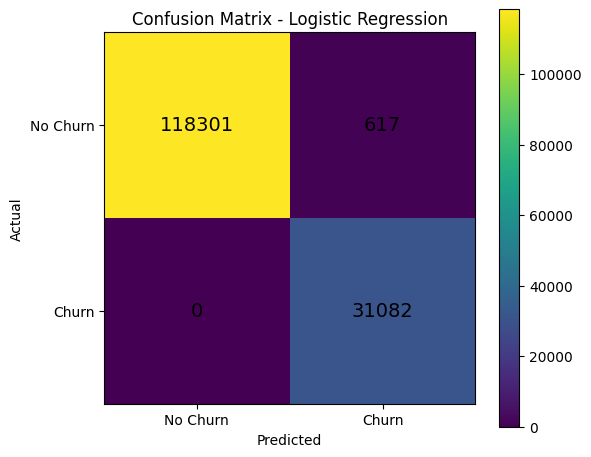

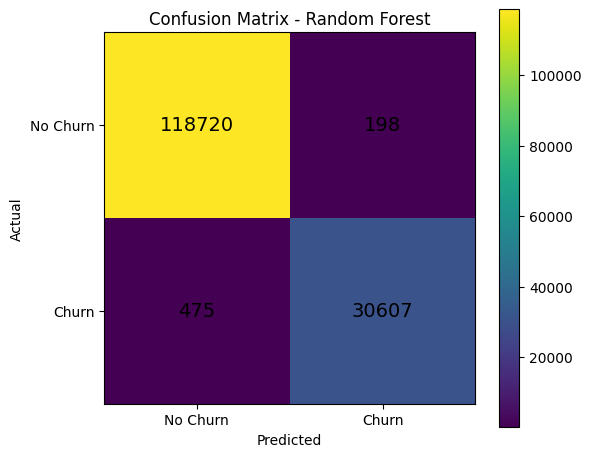

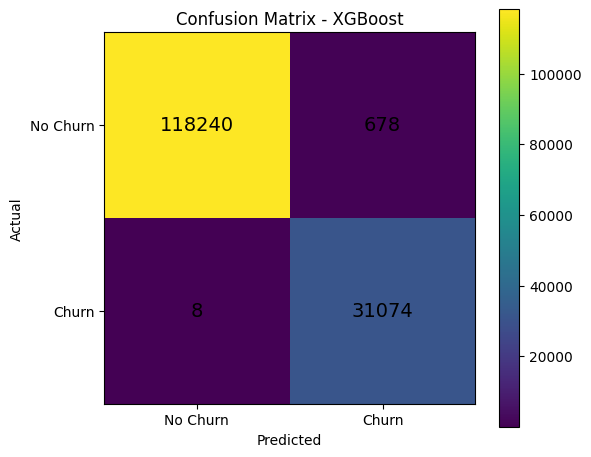

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


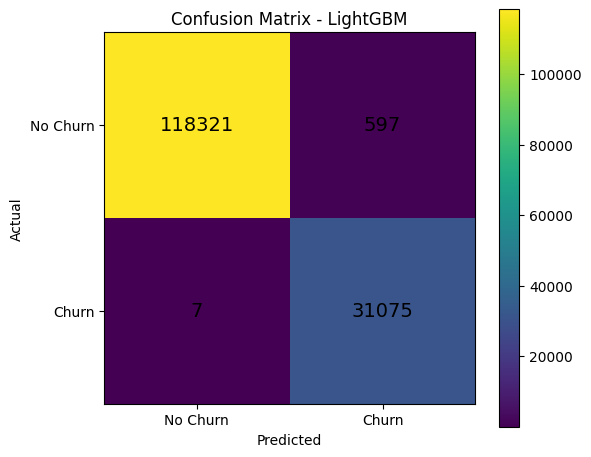

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Models
models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

# Plot confusion matrix for each model
for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create plot
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()

    # Axis labels
    plt.xticks([0, 1], ["No Churn", "Churn"])
    plt.yticks([0, 1], ["No Churn", "Churn"])

    # Add values inside boxes
    for i in range(2):
        for j in range(2):
            plt.text(
                j, i, cm[i, j],
                ha="center",
                va="center",
                fontsize=14
            )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()